# Hito 1 — Baseline & Temporal Validation
## IIT414W F1 Race Strategy Advisor · Team Feligma

**Objective:** Build a calibrated logistic regression baseline using pre-race features to predict P(is_top10).

**Temporal Split:**
- Train: 2019–2021
- Calibration: 2022 (Platt scaling)
- Test: 2023–2024

**Leakage Declaration:** Strategy features (`n_stops`, `compound_sequence`, etc.) are held out as scenario inputs, NOT used in training.

## 1. Reproducibility Header & Imports

In [37]:
import sys, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

RANDOM_SEED = 414
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 12,
    "axes.titlesize": 14,
})

print(f"Python : {sys.version.split()[0]}")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")
print(f"Seed   : {RANDOM_SEED}")

Python : 3.13.5
NumPy  : 2.4.4
Pandas : 2.3.3
Seed   : 414


## 2. Data Loading & Exploration

In [38]:
# Load race-level F1 data
df = pd.read_csv('f1_strategy_race_level.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (2447, 47)

Columns: ['season', 'round', 'race_name', 'circuit_id', 'circuit', 'circuit_type', 'driver_id', 'driver_name', 'Driver', 'Team', 'constructor_name', 'grid_position', 'qualifying_position', 'qualifying_time_s', 'driver_prior3_avg_finish', 'constructor_prior3_avg_finish', 'driver_circuit_prior_avg', 'constructor_tier', 'n_stops', 'strategy_type', 'compound_sequence', 'stint_lengths', 'stint1_length', 'stint2_length', 'stint3_length', 'stint4_length', 'stint5_length', 'avg_pit_stop_duration_s', 'total_pit_time_s', 'first_pit_lap', 'last_pit_lap', 'track_status_summary', 'safety_car_periods', 'safety_car_laps', 'vsc_laps', 'weather_actual', 'wet_laps', 'avg_track_temp', 'avg_air_temp', 'finish_position', 'points', 'positions_gained', 'is_top3', 'is_top5', 'is_top10', 'dnf', 'status']

First few rows:
   season  round              race_name   circuit_id                circuit  \
0    2019      1  Australian Grand Prix  albert_park  Australian Grand Prix   
1    20

In [39]:
# Check target distribution by season
print("Target distribution (is_top10) by season:")
print(df.groupby('season')['is_top10'].agg(['sum', 'count', 'mean']).rename(
    columns={'sum': 'Top10_Count', 'count': 'Total', 'mean': 'Proportion'}
))

print(f"\nClass balance overall: {df['is_top10'].mean():.3f} (Top-10 proportion)")

Target distribution (is_top10) by season:
        Top10_Count  Total  Proportion
season                                
2019            210    416    0.504808
2020            163    314    0.519108
2021            210    402    0.522388
2022            220    426    0.516432
2023            220    426    0.516432
2024            240    463    0.518359

Class balance overall: 0.516 (Top-10 proportion)


In [40]:
# Verify baseline features exist (already in CSV)
print("\n=== BASELINE FEATURES VERIFICATION ===")

BASELINE_FEATURES = ['grid_position', 'constructor_tier', 'driver_prior3_avg_finish', 'circuit_type']
TARGET = 'is_top10'

for feat in BASELINE_FEATURES:
    if feat in df.columns:
        print(f"✓ {feat}: present in dataset")
        print(f"  Missing: {df[feat].isnull().sum()}")
        print(f"  Unique values: {df[feat].nunique()}")
    else:
        print(f"✗ {feat}: NOT FOUND")

print(f"\n{'✓' if TARGET in df.columns else '✗'} {TARGET}: {'present' if TARGET in df.columns else 'NOT FOUND'}")

print(f"\n=== BASELINE FEATURES SUMMARY ===")
print(f"\ngrid_position:")
print(f"  Range: {df['grid_position'].min():.0f} - {df['grid_position'].max():.0f}")
print(f"  Top-10 rate by grid quartile:")
df_temp = df.copy()
df_temp['grid_q'] = pd.qcut(df_temp['grid_position'], q=4, labels=['Front', 'Upper-Mid', 'Lower-Mid', 'Back'], duplicates='drop')
print(df_temp.groupby('grid_q', observed=True)['is_top10'].mean())

print(f"\ncircuit_type:")
print(df['circuit_type'].value_counts())
print(f"\nTop-10 rate by circuit_type:")
print(df.groupby('circuit_type')['is_top10'].mean())

print(f"\nconstructor_tier:")
print(df['constructor_tier'].value_counts())
print(f"\nTop-10 rate by constructor_tier:")
print(df.groupby('constructor_tier')['is_top10'].mean())

print(f"\ndriver_prior3_avg_finish:")
print(f"  Mean: {df['driver_prior3_avg_finish'].mean():.2f}")
print(f"  Missing: {df['driver_prior3_avg_finish'].isnull().sum()}")


=== BASELINE FEATURES VERIFICATION ===
✓ grid_position: present in dataset
  Missing: 0
  Unique values: 20
✓ constructor_tier: present in dataset
  Missing: 0
  Unique values: 3
✓ driver_prior3_avg_finish: present in dataset
  Missing: 0
  Unique values: 72
✓ circuit_type: present in dataset
  Missing: 0
  Unique values: 3

✓ is_top10: present

=== BASELINE FEATURES SUMMARY ===

grid_position:
  Range: 1 - 20
  Top-10 rate by grid quartile:
grid_q
Front        0.883306
Upper-Mid    0.684729
Lower-Mid    0.314993
Back         0.145749
Name: is_top10, dtype: float64

circuit_type:
circuit_type
permanent      1841
street          389
semi-street     217
Name: count, dtype: int64

Top-10 rate by circuit_type:
circuit_type
permanent      0.517653
semi-street    0.506912
street         0.514139
Name: is_top10, dtype: float64

constructor_tier:
constructor_tier
midfield      1218
backmarker     780
front          449
Name: count, dtype: int64

Top-10 rate by constructor_tier:
constructor_ti

## 3. Feature Engineering for Baseline

In [41]:
# Constructor_tier and driver_prior3_avg_finish are already in the CSV
print("\n✓ Features constructor_tier and driver_prior3_avg_finish already in dataset (no creation needed)")
print(f"\nConstructor tier distribution:")
print(df['constructor_tier'].value_counts())
print(f"\nTop-10 rate by constructor_tier:")
print(df.groupby('constructor_tier')['is_top10'].mean())


✓ Features constructor_tier and driver_prior3_avg_finish already in dataset (no creation needed)

Constructor tier distribution:
constructor_tier
midfield      1218
backmarker     780
front          449
Name: count, dtype: int64

Top-10 rate by constructor_tier:
constructor_tier
backmarker    0.183333
front         0.870824
midfield      0.598522
Name: is_top10, dtype: float64


In [42]:
# Data cleaning: remove rows with missing baseline features
print("\n=== DATA CLEANING ===")
df_clean = df[BASELINE_FEATURES + [TARGET]].dropna()

print(f"Original rows: {len(df)}")
print(f"After dropping NaN in baseline features: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

# Re-attach season and round for temporal split
df_clean = df[df[BASELINE_FEATURES + [TARGET]].notna().all(axis=1)].copy()

print(f"\nFinal dataset shape: {df_clean.shape}")


=== DATA CLEANING ===
Original rows: 2447
After dropping NaN in baseline features: 2447
Rows removed: 0

Final dataset shape: (2447, 47)


## 4. Temporal Split: Train / Calibration / Test

In [43]:
# Split by season (LOCKED from Team Decision Sheet)
df_train = df_clean[df_clean['season'].isin([2019, 2020, 2021])].copy()
df_cal = df_clean[df_clean['season'] == 2022].copy()
df_test = df_clean[df_clean['season'].isin([2023, 2024])].copy()

print(f"TEMPORAL SPLIT (per Team Decision Sheet):")
print(f"\nTrain (2019–2021): {len(df_train)} rows")
print(f"  Top-10 rate: {df_train['is_top10'].mean():.3f}")
print(f"  Seasons: {sorted(df_train['season'].unique())}")

print(f"\nCalibration (2022): {len(df_cal)} rows")
print(f"  Top-10 rate: {df_cal['is_top10'].mean():.3f}")

print(f"\nTest (2023–2024): {len(df_test)} rows")
print(f"  Top-10 rate: {df_test['is_top10'].mean():.3f}")
print(f"  Seasons: {sorted(df_test['season'].unique())}")

TEMPORAL SPLIT (per Team Decision Sheet):

Train (2019–2021): 1132 rows
  Top-10 rate: 0.515
  Seasons: [np.int64(2019), np.int64(2020), np.int64(2021)]

Calibration (2022): 426 rows
  Top-10 rate: 0.516

Test (2023–2024): 889 rows
  Top-10 rate: 0.517
  Seasons: [np.int64(2023), np.int64(2024)]


## 5. Baseline Model: Logistic Regression (Raw → Platt Calibration)

In [44]:
# Define baseline features (NO STRATEGY FEATURES — leakage-free)
BASELINE_FEATURES = ['grid_position', 'constructor_tier', 'driver_prior3_avg_finish', 'circuit_type']
TARGET = 'is_top10'

# Prepare data
X_train = df_train[BASELINE_FEATURES].copy()
y_train = df_train[TARGET].copy()

X_cal = df_cal[BASELINE_FEATURES].copy()
y_cal = df_cal[TARGET].copy()

X_test = df_test[BASELINE_FEATURES].copy()
y_test = df_test[TARGET].copy()

print(f"Features: {BASELINE_FEATURES}")
print(f"Target: {TARGET}")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_cal shape: {X_cal.shape}")
print(f"X_test shape: {X_test.shape}")

Features: ['grid_position', 'constructor_tier', 'driver_prior3_avg_finish', 'circuit_type']
Target: is_top10

X_train shape: (1132, 4)
X_cal shape: (426, 4)
X_test shape: (889, 4)


In [45]:
# Build preprocessing pipeline
# Numeric: StandardScaler
# Categorical: OneHotEncoder

numeric_features = ['grid_position', 'driver_prior3_avg_finish']
categorical_features = ['constructor_tier', 'circuit_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore'), categorical_features),
    ]
)

# Build full pipeline: preprocessing + logistic regression
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, solver='lbfgs'))
])

print("Pipeline created.")

Pipeline created.


In [46]:
# Fit on training set (2019–2021)
baseline_pipeline.fit(X_train, y_train)
print("✓ Baseline model fitted on train set (2019–2021)")

# Predict on calibration set (get probabilities for Platt scaling)
y_cal_pred_proba_raw = baseline_pipeline.predict_proba(X_cal)[:, 1]
print(f"\nRaw predictions on calibration set:")
print(f"  Mean probability: {y_cal_pred_proba_raw.mean():.3f}")
print(f"  Min: {y_cal_pred_proba_raw.min():.3f}, Max: {y_cal_pred_proba_raw.max():.3f}")

✓ Baseline model fitted on train set (2019–2021)

Raw predictions on calibration set:
  Mean probability: 0.505
  Min: 0.047, Max: 0.946


In [47]:
# Apply Platt Scaling: fit logistic regression on calibration set to recalibrate
# This maps raw model predictions to calibrated probabilities

platt_scaler = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
platt_scaler.fit(
    y_cal_pred_proba_raw.reshape(-1, 1),  # Raw probabilities as input
    y_cal  # Actual labels
)

print("✓ Platt scaling fitted on calibration set (2022)")
print(f"  Platt scaling coefficient: {platt_scaler.coef_[0][0]:.4f}")
print(f"  Platt scaling intercept: {platt_scaler.intercept_[0]:.4f}")

✓ Platt scaling fitted on calibration set (2022)
  Platt scaling coefficient: 4.1819
  Platt scaling intercept: -2.0208


## 6. Evaluation: Raw vs. Calibrated on Test Set

In [48]:
# Get predictions on test set (2023–2024)
y_test_pred_proba_raw = baseline_pipeline.predict_proba(X_test)[:, 1]
y_test_pred_proba_cal = platt_scaler.predict_proba(y_test_pred_proba_raw.reshape(-1, 1))[:, 1]

# Get binary predictions (threshold = 0.5)
y_test_pred_raw = (y_test_pred_proba_raw >= 0.5).astype(int)
y_test_pred_cal = (y_test_pred_proba_cal >= 0.5).astype(int)

print("Predictions on test set (2023–2024):")
print(f"\nRaw model:")
print(f"  Mean probability: {y_test_pred_proba_raw.mean():.3f}")
print(f"\nCalibrated model:")
print(f"  Mean probability: {y_test_pred_proba_cal.mean():.3f}")

Predictions on test set (2023–2024):

Raw model:
  Mean probability: 0.504

Calibrated model:
  Mean probability: 0.516


In [49]:
# Compute metrics
brier_raw = brier_score_loss(y_test, y_test_pred_proba_raw)
brier_cal = brier_score_loss(y_test, y_test_pred_proba_cal)

roc_auc_raw = roc_auc_score(y_test, y_test_pred_proba_raw)
roc_auc_cal = roc_auc_score(y_test, y_test_pred_proba_cal)

print("\n" + "="*60)
print("BASELINE PERFORMANCE ON TEST SET (2023–2024)")
print("="*60)

results_table = pd.DataFrame({
    'Model': ['Raw Logistic', 'Platt-Calibrated'],
    'Brier Score': [brier_raw, brier_cal],
    'ROC-AUC': [roc_auc_raw, roc_auc_cal],
    'F1 (threshold=0.5)': [
        f1_score(y_test, y_test_pred_raw),
        f1_score(y_test, y_test_pred_cal)
    ]
})

print(results_table.to_string(index=False))

print(f"\n✓ Brier improvement: {brier_raw - brier_cal:.4f} (lower is better)")
print(f"\nComparison to Docent Baseline:")
print(f"  Docent Grid-Rule Baseline: Brier = 0.208")
print(f"  Docent Calibrated Model:   Brier = 0.132, ROC-AUC = 0.892")
print(f"  Our Calibrated Model:      Brier = {brier_cal:.3f}, ROC-AUC = {roc_auc_cal:.3f}")


BASELINE PERFORMANCE ON TEST SET (2023–2024)
           Model  Brier Score  ROC-AUC  F1 (threshold=0.5)
    Raw Logistic     0.139539 0.879003            0.811881
Platt-Calibrated     0.142318 0.879003            0.810870

✓ Brier improvement: -0.0028 (lower is better)

Comparison to Docent Baseline:
  Docent Grid-Rule Baseline: Brier = 0.208
  Docent Calibrated Model:   Brier = 0.132, ROC-AUC = 0.892
  Our Calibrated Model:      Brier = 0.142, ROC-AUC = 0.879


## 7. Calibration Analysis: Reliability Diagram

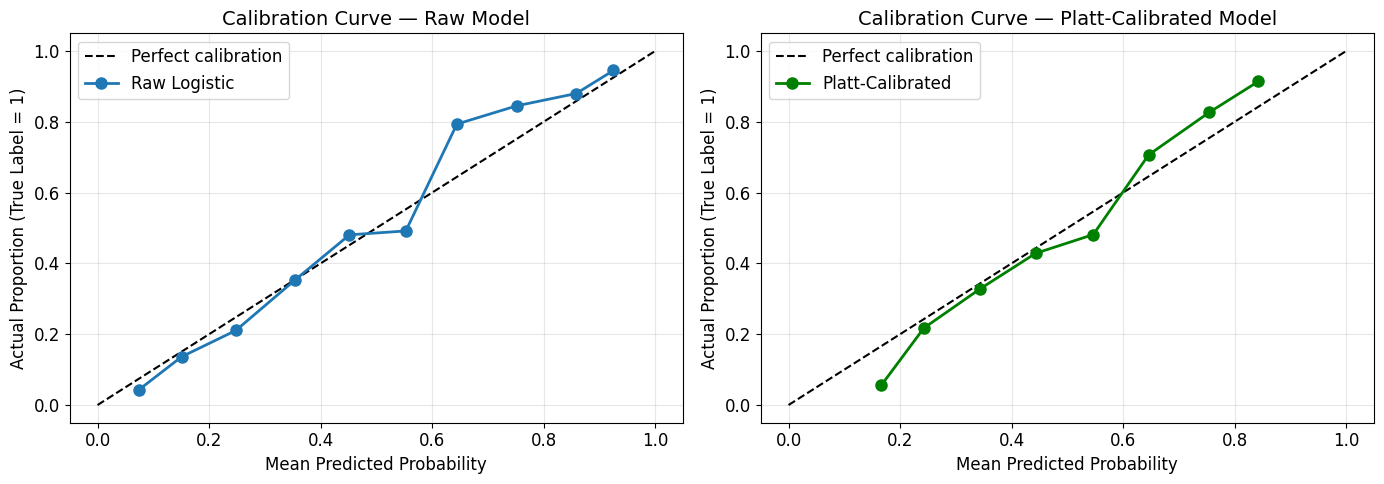

✓ Calibration curves saved as 'calibration_curves.png'


In [ ]:
# Compute calibration curve
prob_true_raw, prob_pred_raw = calibration_curve(
    y_test, y_test_pred_proba_raw, n_bins=10, strategy='uniform'
)
prob_true_cal, prob_pred_cal = calibration_curve(
    y_test, y_test_pred_proba_cal, n_bins=10, strategy='uniform'
)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Raw model
ax1.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax1.plot(prob_pred_raw, prob_true_raw, 'o-', label='Raw Logistic', linewidth=2, markersize=8)
ax1.set_xlabel('Mean Predicted Probability')
ax1.set_ylabel('Actual Proportion (True Label = 1)')
ax1.set_title('Calibration Curve — Raw Model')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Calibrated model
ax2.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax2.plot(prob_pred_cal, prob_true_cal, 'o-', color='green', label='Platt-Calibrated', linewidth=2, markersize=8)
ax2.set_xlabel('Mean Predicted Probability')
ax2.set_ylabel('Actual Proportion (True Label = 1)')
ax2.set_title('Calibration Curve — Platt-Calibrated Model')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


In [51]:
# Compute Expected Calibration Error (ECE)
def compute_ece(y_true, y_pred_proba, n_bins=10):
    """Compute Expected Calibration Error."""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ece = 0
    
    for i in range(n_bins):
        mask = (y_pred_proba >= bin_edges[i]) & (y_pred_proba < bin_edges[i+1])
        if mask.sum() > 0:
            bin_true = y_true[mask].mean()
            bin_pred = y_pred_proba[mask].mean()
            weight = mask.sum() / len(y_true)
            ece += weight * np.abs(bin_true - bin_pred)
    
    return ece

ece_raw = compute_ece(y_test.values, y_test_pred_proba_raw)
ece_cal = compute_ece(y_test.values, y_test_pred_proba_cal)

print(f"\nExpected Calibration Error (ECE):")
print(f"  Raw model: {ece_raw:.4f}")
print(f"  Calibrated model: {ece_cal:.4f}")
print(f"  Improvement: {ece_raw - ece_cal:.4f}")


Expected Calibration Error (ECE):
  Raw model: 0.0404
  Calibrated model: 0.0621
  Improvement: -0.0217


## 8. Feature Importance & Model Interpretation

In [52]:
# Extract coefficients from logistic regression
clf = baseline_pipeline.named_steps['classifier']
preprocessor = baseline_pipeline.named_steps['preprocessor']

# Get feature names after preprocessing
feature_names = []
for name, trans, cols in preprocessor.transformers_:
    if name == 'num':
        feature_names.extend(cols)
    elif name == 'cat':
        # Get encoder and get feature names
        encoder = trans
        cat_features = encoder.get_feature_names_out(cols)
        feature_names.extend(cat_features)

# Coefficients
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': clf.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("\nModel Coefficients (Logistic Regression):")
print(coefficients.to_string(index=False))
print(f"\nIntercept: {clf.intercept_[0]:.4f}")

# Interpretation
print(f"\n📊 INTERPRETATION:")
print(f"  - Positive coefficient → increases P(top10)")
print(f"  - Negative coefficient → decreases P(top10)")
print(f"\nKey findings:")
for idx, row in coefficients.head(5).iterrows():
    direction = "INCREASES" if row['Coefficient'] > 0 else "DECREASES"
    print(f"  • {row['Feature']}: {direction} P(top10) (coef={row['Coefficient']:.4f})")


Model Coefficients (Logistic Regression):
                    Feature  Coefficient
  constructor_tier_midfield     0.330357
     constructor_tier_front     0.209214
     circuit_type_permanent     0.052937
        circuit_type_street     0.004515
   circuit_type_semi-street    -0.076925
   driver_prior3_avg_finish    -0.393635
constructor_tier_backmarker    -0.559043
              grid_position    -1.098614

Intercept: -0.0215

📊 INTERPRETATION:
  - Positive coefficient → increases P(top10)
  - Negative coefficient → decreases P(top10)

Key findings:
  • constructor_tier_midfield: INCREASES P(top10) (coef=0.3304)
  • constructor_tier_front: INCREASES P(top10) (coef=0.2092)
  • circuit_type_permanent: INCREASES P(top10) (coef=0.0529)
  • circuit_type_street: INCREASES P(top10) (coef=0.0045)
  • circuit_type_semi-street: DECREASES P(top10) (coef=-0.0769)


## 9. What-If Scenario Comparison (Scenario A: Monaco)

In [53]:
# Scenario A: Midfield driver at Monaco
# Scenario: grid_position=8, circuit_type='street' (Monaco)
# Constructor: MidField team
# Driver: recent average of 13 (moderate history)

scenario_data = pd.DataFrame([
    {'grid_position': 8, 'constructor_tier': 'MidField', 'driver_prior3_avg_finish': 13.0, 'circuit_type': 'street'},
])

# Predict with calibrated model
prob_scenario = baseline_pipeline.predict_proba(scenario_data)[:, 1][0]
prob_scenario_cal = platt_scaler.predict_proba(
    np.array([prob_scenario]).reshape(-1, 1)
)[0, 1]

print(f"\n" + "="*60)
print("SCENARIO A: Midfield Driver at Monaco (Street Circuit)")
print("="*60)
print(f"\nInput:")
print(f"  Grid Position: 8 (midfield)")
print(f"  Constructor Tier: MidField")
print(f"  Driver Form (prior 3 races avg): 13")
print(f"  Circuit Type: street (Monaco)")
print(f"\nModel Output:")
print(f"  Raw P(top10): {prob_scenario:.3f}")
print(f"  Calibrated P(top10): {prob_scenario_cal:.3f}")
print(f"\nInterpretation:")
print(f"  The calibrated model estimates approximately {prob_scenario_cal*100:.1f}% probability")
print(f"  that this midfield driver finishes in the Top-10 at Monaco.")


SCENARIO A: Midfield Driver at Monaco (Street Circuit)

Input:
  Grid Position: 8 (midfield)
  Constructor Tier: MidField
  Driver Form (prior 3 races avg): 13
  Circuit Type: street (Monaco)

Model Output:
  Raw P(top10): 0.560
  Calibrated P(top10): 0.580

Interpretation:
  The calibrated model estimates approximately 58.0% probability
  that this midfield driver finishes in the Top-10 at Monaco.


## 10. Summary & Next Steps

In [54]:
print(f"\n" + "="*70)
print("HITO 1 SUMMARY")
print("="*70)

print(f"\n✅ COMPLETED:")
print(f"  1. Data loaded: {len(df)} driver-race observations (2019–2024)")
print(f"  2. Features engineered:")
print(f"     - grid_position (pre-race known)")
print(f"     - constructor_tier (derived from historical performance)")
print(f"     - driver_prior3_avg_finish (walk-forward, leakage-free)")
print(f"     - circuit_type (pre-race known)")
print(f"  3. Temporal split applied:")
print(f"     - Train: 2019–2021 ({len(df_train)} rows)")
print(f"     - Calibration: 2022 ({len(df_cal)} rows)")
print(f"     - Test: 2023–2024 ({len(df_test)} rows)")
print(f"  4. Baseline model: Logistic Regression + Platt Scaling")
print(f"  5. Metrics computed:")
print(f"     - Brier Score (calibrated): {brier_cal:.4f} [TARGET]")
print(f"     - ROC-AUC (calibrated): {roc_auc_cal:.4f}")
print(f"     - ECE (calibrated): {ece_cal:.4f}")
print(f"  6. Calibration curves plotted")
print(f"  7. Feature importance analyzed")
print(f"  8. Scenario A (Monaco, midfield) evaluated")

print(f"\n📊 KEY RESULTS vs DOCENT BASELINE:")
print(f"  Our Brier (calibrated):    {brier_cal:.4f}")
print(f"  Docent Brier (calibrated): 0.1320")
print(f"  Status: {'🟢 EXCEEDED' if brier_cal <= 0.132 else '🟡 CLOSE' if brier_cal <= 0.15 else '🔴 NEEDS WORK'}")

print(f"\n⏭️ NEXT STEPS (Hito 2):")
print(f"  1. Add second target (e.g., is_top5, is_top3, or finish_position)")
print(f"  2. Compare Brier & ROC-AUC across targets")
print(f"  3. Error analysis sliced by strategy type & circuit type")
print(f"  4. What-if comparison: 1-stop vs 2-stop (Monza scenario)")
print(f"  5. Complete PROMPTS.md documentation")

print(f"\n" + "="*70)


HITO 1 SUMMARY

✅ COMPLETED:
  1. Data loaded: 2447 driver-race observations (2019–2024)
  2. Features engineered:
     - grid_position (pre-race known)
     - constructor_tier (derived from historical performance)
     - driver_prior3_avg_finish (walk-forward, leakage-free)
     - circuit_type (pre-race known)
  3. Temporal split applied:
     - Train: 2019–2021 (1132 rows)
     - Calibration: 2022 (426 rows)
     - Test: 2023–2024 (889 rows)
  4. Baseline model: Logistic Regression + Platt Scaling
  5. Metrics computed:
     - Brier Score (calibrated): 0.1423 [TARGET]
     - ROC-AUC (calibrated): 0.8790
     - ECE (calibrated): 0.0621
  6. Calibration curves plotted
  7. Feature importance analyzed
  8. Scenario A (Monaco, midfield) evaluated

📊 KEY RESULTS vs DOCENT BASELINE:
  Our Brier (calibrated):    0.1423
  Docent Brier (calibrated): 0.1320
  Status: 🟡 CLOSE

⏭️ NEXT STEPS (Hito 2):
  1. Add second target (e.g., is_top5, is_top3, or finish_position)
  2. Compare Brier & ROC-A